In [10]:
from dotenv import load_dotenv
import os
from langgraph.graph import StateGraph, START, END
from typing import Annotated, Sequence, List, Optional
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from operator import add as add_messages
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace, HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from pydantic import BaseModel, FilePath
import pandas as pd
import polars
from IPython.display import Image, display

In [2]:
@tool
def extract_columns(file_path:FilePath) -> List[str]:
    """
    This tool reads and extracts column name and description from the file
    Args:
        file_path (str): metadata file path 
    
    Return:
        Metadata object contains column name and brief column description
    """
    if not os.path.exists(file_path):
        return []
    
    _, file_extension = os.path.splitext(file_path)
    
    cols = []
    
    try:
        if file_extension == '.csv':
            df = polars.read_csv(file_path, nrows=0)
            cols = df.columns.tolist()
        elif file_extension in ['.xlsx', '.xls']:
            df = polars.read_excel(file_path, nrows=0)
            cols = df.columns.tolist()
        elif file_extension == '.json':
            df = polars.read_json(file_path)
            cols = df.columns.tolist()
    except Exception as e:
        return str(e)

    # res = []
    # for c in cols:
    #     description = describe_column(c)
    #     res.append(MetaData(col_name=c, col_desc=description))

    return cols

In [ ]:
class AgentState(BaseModel):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    cols: Optional[str] 
    metadata: Optional[str]

In [12]:
hf_endpoint = HuggingFaceEndpoint(
    repo_id='Qwen/Qwen2.5-7B-Instruct',
)

llm = ChatHuggingFace(llm=hf_endpoint).bind_tools(tools=[extract_columns])

In [13]:
def extract_metadata_node(cols: List[str], state:AgentState) -> AgentState:
    for c in cols:
        messages = [
            SystemMessage(content="You are a helpful assistant that writes short dataset column descriptions."),
            HumanMessage(content=f"Provide a concise plain-language description for the dataset column named '{c}'.\
                                    Format your answer like this: column_name: column_metadata.\
                                    Don't return anything else")
        ]
        response = llm.invoke(messages)
    return {'metadata': response['messages'], 'cols':cols, }

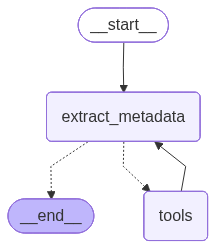

In [14]:
graph = StateGraph(AgentState)
graph.add_node('extract_metadata', extract_metadata_node)
graph.add_node('tools', ToolNode)

graph.add_edge(START, 'extract_metadata')
graph.add_conditional_edges(
    'extract_metadata',
    tools_condition
)
graph.add_edge('tools', 'extract_metadata')

app = graph.compile()

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [18]:
user_input = input("Enter: ")
while user_input != 'exit':
    app.invoke({'messages': [HumanMessage(content=user_input)]})
    print('\n')
    user_input = input("Enter:")

ValidationError: 3 validation errors for AgentState
filePath
  Field required [type=missing, input_value={'messages': [HumanMessag... response_metadata={})]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
cols
  Field required [type=missing, input_value={'messages': [HumanMessag... response_metadata={})]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
metadata
  Field required [type=missing, input_value={'messages': [HumanMessag... response_metadata={})]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing